# Milestone 3: Transfer Learning für Galaxy10 DECals

In diesem Notebook wenden wir **Transfer Learning** auf etablierte reine CNN-Architekturen an (keine Transformer). 
Wir vergleichen drei verschiedene Backbones:
1. **ResNet50** (Residual Networks)
2. **InceptionV3** (GoogLeNet Architektur)
3. **EfficientNetB0** (Die Standard-Architektur für astronomische Zoobot-Modelle)

Das Notebook nutzt unsere bestehende K-Fold-Pipeline aus `train.py` und die Evaluierungstools aus `evaluate.py`.

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50, InceptionV3, EfficientNetB0, ResNet152

# Importiere aus deinen lokalen Skripten
from data import load_data, prepare_splits, INPUT_SHAPE, NUM_CLASSES
from train import run_training
from evaluate import evaluate_models, plot_confusion_matrix, plot_training_history

print(f"TensorFlow Version: {tf.__version__}")
print(f"Input Shape: {INPUT_SHAPE}")
print(f"Anzahl Klassen: {NUM_CLASSES}")

TensorFlow Version: 2.21.0
Input Shape: (256, 256, 3)
Anzahl Klassen: 10


In [14]:
# --- Experiment-Schalter ---
USE_KFOLD   = False   # True = 5-fache Kreuzvalidierung | False = einfacher Train/Val-Split
LOAD_MODELS = False   # True = gespeicherte Checkpoints laden statt neu trainieren

# --- Datenpfade ---
DATA_PATH = './../data/Galaxy10_DECals.h5'
LOGS_DIR  = './../logs/'

# --- Hyperparameter ---
BATCH_SIZE     = 16
EPOCHS         = 20
LEARNING_RATE  = 1e-4
K_FOLDS        = 5      # nur relevant wenn USE_KFOLD = True
RANDOM_STATE   = 42

## 1. Daten laden und Splits vorbereiten
Wir laden die Bilder vollständig in den RAM (als `uint8`) und erzeugen die Indizes für unser K-Fold Cross-Validation Setup (inklusive separatem Test-Set).

In [15]:
print("Lade Datensatz in den RAM...")
images_raw, labels = load_data(DATA_PATH)

print("Erstelle Train/Val Folds und Test-Split...")
folds, X_test, y_test = prepare_splits(
    labels,
    use_kfold    = USE_KFOLD,
    k            = K_FOLDS,
    random_state = RANDOM_STATE,
)

print(f"Anzahl Folds: {len(folds)}")
print(f"Bilder im Test-Set: {len(X_test)}")

Lade Datensatz in den RAM...
Dataset geladen: 17,736 Bilder, Shape (17736, 256, 256, 3)
Erstelle Train/Val Folds und Test-Split...

Split-Modus : Einfacher Train/Val-Split
Train + Val : 14,188 Samples
Test        : 3,548 Samples
  Train 11,350 | Val 2,838
Anzahl Folds: 1
Bilder im Test-Set: 3548


## 2. Transfer Learning Helfer & Model Factories

Da unsere `run_training` Funktion für jeden Fold ein völlig **unbelastetes**, frisches Modell benötigt, definieren wir eine Basis-Funktion und sogenannte "Factories" (Funktionen, die bei Aufruf ein neues Modell zurückgeben).

In [ ]:
def build_transfer_model(base_model, model_name, learning_rate=1e-4):
    """
    Kapselt das eingefrorene Basis-Modell und setzt einen neuen Kopf auf.
    """
    # Gewichte des vortrainierten Modells einfrieren
    base_model.trainable = False 
    
    inputs = Input(shape=INPUT_SHAPE)
    
    # training=False sorgt dafür, dass BatchNormalization im Inference-Modus bleibt
    x = base_model(inputs, training=False)
    
    # Klassifizierungs-Kopf (Top)
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dense(256, activation='relu', name="dense_256")(x)
    x = BatchNormalization(name="bn_1")(x)
    x = Dropout(0.5, name="dropout_1")(x)
    
    outputs = Dense(NUM_CLASSES, activation='softmax', name="predictions")(x)
    
    model = Model(inputs=inputs, outputs=outputs, name=model_name)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# --- Model Factories ---

def resnet50_factory():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    return build_transfer_model(base, "ResNet50_Transfer", learning_rate=LEARNING_RATE)

def resnet152_factory():
    base = ResNet152(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    return build_transfer_model(base, "ResNet152_Transfer", learning_rate=LEARNING_RATE)

def inception_factory():
    base = InceptionV3(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    return build_transfer_model(base, "InceptionV3_Transfer", learning_rate=LEARNING_RATE)

def zoobot_factory():
    # EfficientNetB0 ist die Basis der meisten offiziellen Zoobot-Modelle
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    return build_transfer_model(base, "Zoobot_EfficientNetB0_Transfer", learning_rate=LEARNING_RATE)

## 3. Training der Modelle

Wir iterieren über unsere definierten Factories und lassen jedes Modell durch unsere `run_training`-Schleife laufen.  
*Hinweis: Da die Modelle recht groß sind, setzen wir die `batch_size` hier konservativ auf 16, um OOM (Out of Memory) Fehler auf der GPU zu vermeiden.*

In [ ]:
# Alle Modelle, die wir testen wollen
models_to_train = {
    # "ResNet50": resnet50_factory,
    "ResNet152": resnet152_factory,
    # "InceptionV3": inception_factory,
    # "Zoobot_EfficientNetB0": zoobot_factory
}

# Hier speichern wir die Ergebnisse für die spätere Evaluierung
training_results = {}


for model_name, factory in models_to_train.items():
    print(f"\n{'=' * 80}")
    print(f"STARTE TRAINING FÜR: {model_name}")
    print(f"{'=' * 80}")

    factory().summary()  # Zeige die Architektur des Modells an
    
    log_dir = f"{LOGS_DIR}/transfer_learning/{model_name.lower()}"
    
    fold_models, fold_histories = run_training(
        folds=folds,
        images_raw=images_raw,
        labels=labels,
        logs_dir=log_dir,
        model_factory=factory,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        early_stopping_patience=5,
        reduce_lr_patience=2,
        load_models=LOAD_MODELS  # Auf True setzen, falls das Training unterbrochen wurde und fortgesetzt werden soll
    )
    
    training_results[model_name] = {
        "models": fold_models,
        "histories": fold_histories,
        "log_dir": log_dir
    }


STARTE TRAINING FÜR: ResNet50

Fold 1 / 1: Starte Training


/home/alexa/Projects/deep-learning/tf-gpu-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1779806465.178452    8621 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1779806469.477525    8838 service.cc:153] XLA service 0x7c621c035d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779806469.477571    8838 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2070 SUPER, Compute Capability 7.5 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1779806469.685032    8838 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779806471.003707    8838 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1779806471.128004    8838 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20476__.192


  1/710 ━━━━━━━━━━━━━━━━━━━━ 2:17:36 12s/step - accuracy: 0.2500 - loss: 2.2497

...

710/710 ━━━━━━━━━━━━━━━━━━━━ 60s 63ms/step - accuracy: 0.3993 - loss: 1.8402 - val_accuracy: 0.5130 - val_loss: 1.3772 - learning_rate: 1.0000e-04
Epoch 2/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.4835 - loss: 1.5020 - val_accuracy: 0.5352 - val_loss: 1.3136 - learning_rate: 1.0000e-04
Epoch 3/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.5087 - loss: 1.3961 - val_accuracy: 0.5793 - val_loss: 1.1868 - learning_rate: 1.0000e-04
Epoch 4/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5393 - loss: 1.3243 - val_accuracy: 0.5948 - val_loss: 1.1707 - learning_rate: 1.0000e-04
Epoch 5/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5564 - loss: 1.2522 - val_accuracy: 0.5980 - val_loss: 1.1542 - learning_rate: 1.0000e-04
Epoch 6/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.5715 - loss: 1.2190 - val_accuracy: 0.5927 - val_loss: 1.1502 - learning_rate: 1.0000e-04
Epoch 7/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accurac

I0000 00:00:1779807667.338752    8834 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_466386__.261
E0000 00:00:1779807669.693621    8834 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779807672.186125    8834 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


594/710 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.1068 - loss: 2.5366

I0000 00:00:1779807703.892146    8837 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_466386__.261
E0000 00:00:1779807705.891011    8837 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


710/710 ━━━━━━━━━━━━━━━━━━━━ 74s 66ms/step - accuracy: 0.1111 - loss: 2.4662 - val_accuracy: 0.1490 - val_loss: 3.2030 - learning_rate: 1.0000e-04
Epoch 2/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.1315 - loss: 2.3300 - val_accuracy: 0.1057 - val_loss: 3.5553 - learning_rate: 1.0000e-04
Epoch 3/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.1330 - loss: 2.2893 - val_accuracy: 0.1142 - val_loss: 2.7009 - learning_rate: 1.0000e-04
Epoch 4/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.1438 - loss: 2.2636 - val_accuracy: 0.1483 - val_loss: 2.4883 - learning_rate: 1.0000e-04
Epoch 5/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.1443 - loss: 2.2476 - val_accuracy: 0.0803 - val_loss: 2.3763 - learning_rate: 1.0000e-04
Epoch 6/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.1470 - loss: 2.2396 - val_accuracy: 0.1057 - val_loss: 2.3176 - learning_rate: 1.0000e-04
Epoch 7/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accurac

## 4. Evaluierung & Ergebnisse

Jetzt, da alle Architekturen trainiert sind (bzw. die Checkpoints geladen wurden), nutzen wir unsere `evaluate.py` Methoden, um die Accuracy auf dem gemeinsamen Test-Set zu ermitteln und die Ergebnisse zu plotten.



********************************************************************************
EVALUIERUNG FÜR: ResNet50
********************************************************************************
Training History gespeichert: ./../logs//transfer_learning/resnet50/training_history.png


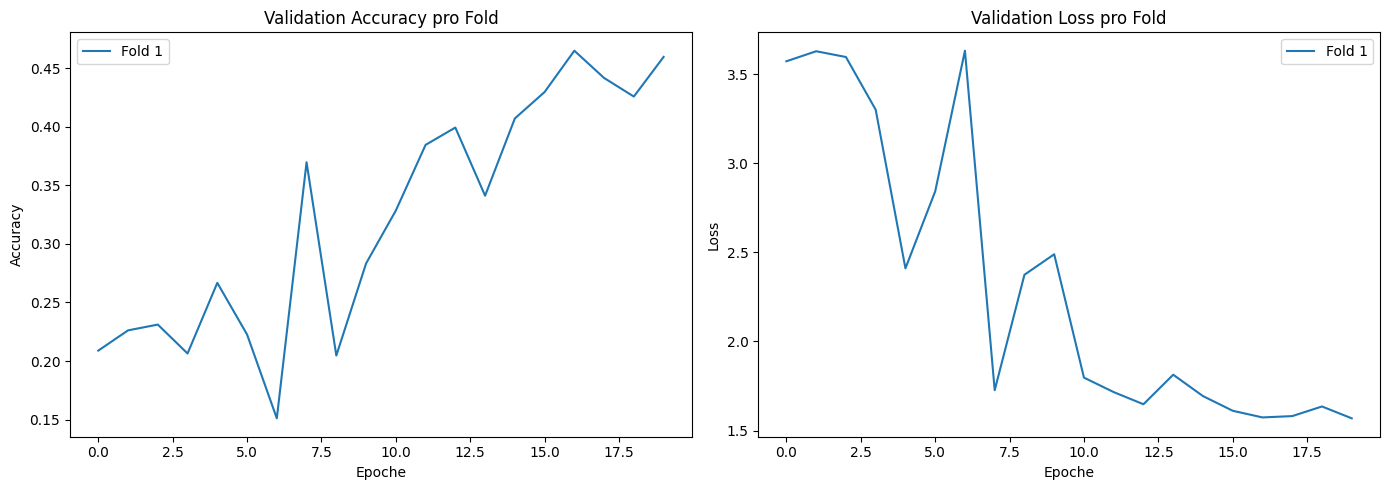

Starte Evaluierung auf dem Test-Set...

  Fold 1 / 1:
  3/222 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4062 - loss: 1.7110 

/home/alexa/Projects/deep-learning/tf-gpu-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.4484 - loss: 1.6102
  --> Test Accuracy: 0.4484 (44.84 %)

Durchschnittliche Test Accuracy : 0.4484
Standardabweichung              : 0.0000
Bestes Modell                   : Fold 1
  Test Accuracy                 : 0.4484 (44.84 %)
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step
Confusion Matrix gespeichert: ./../logs//transfer_learning/resnet50/confusion_matrix.png


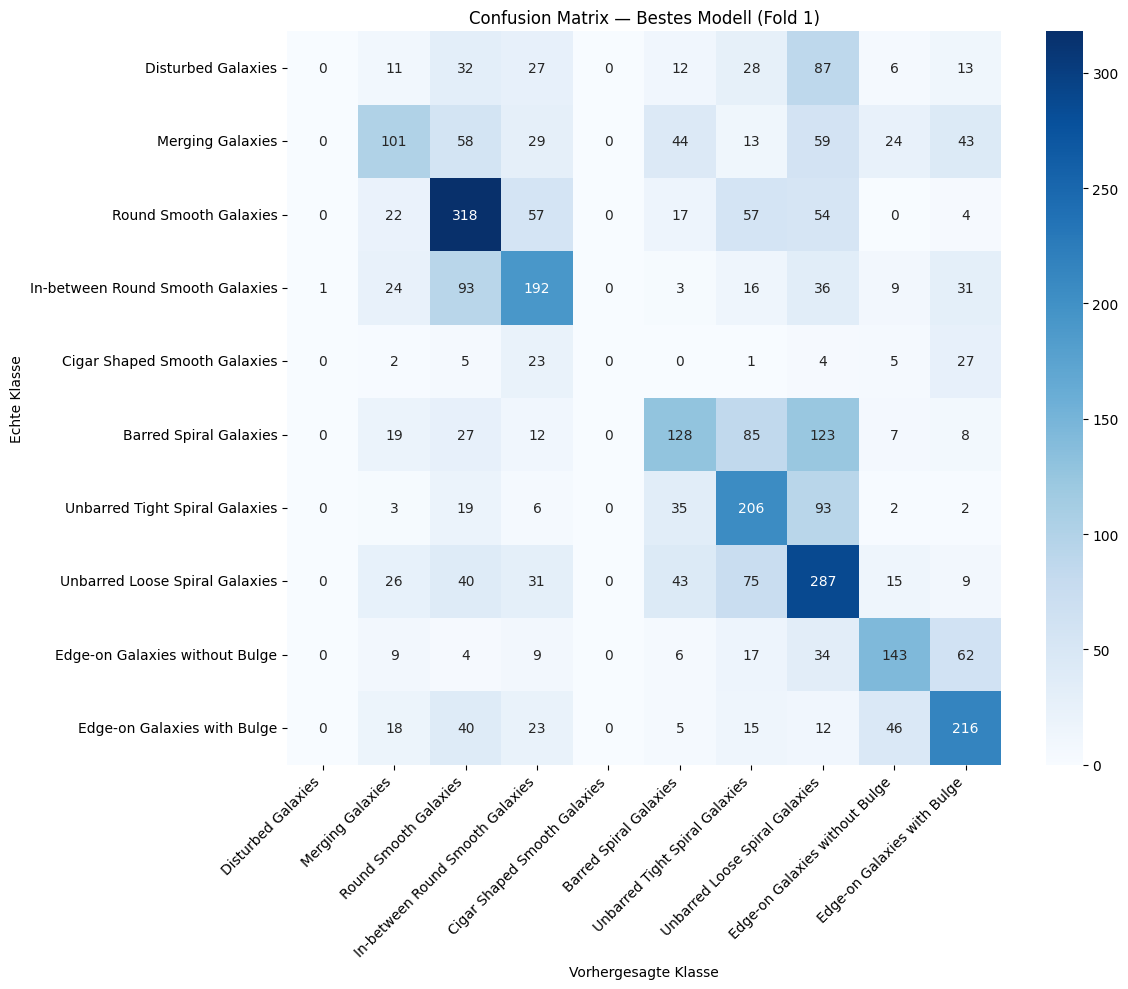



********************************************************************************
EVALUIERUNG FÜR: InceptionV3
********************************************************************************
Training History gespeichert: ./../logs//transfer_learning/inceptionv3/training_history.png


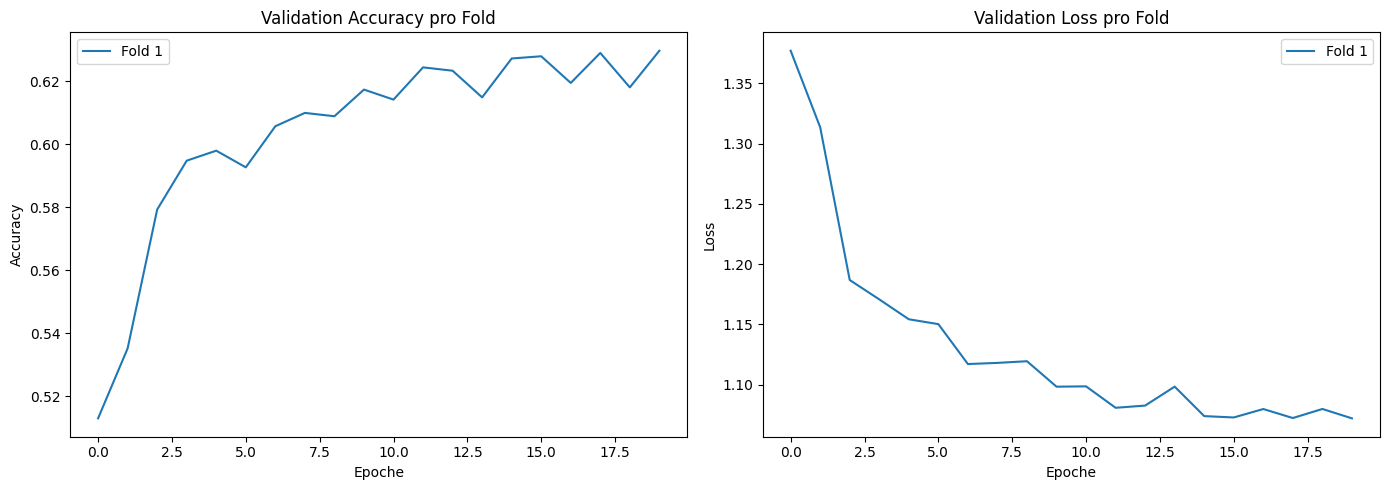

Starte Evaluierung auf dem Test-Set...

  Fold 1 / 1:
  1/222 ━━━━━━━━━━━━━━━━━━━━ 32s 146ms/step - accuracy: 0.7500 - loss: 0.8361

/home/alexa/Projects/deep-learning/tf-gpu-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.6105 - loss: 1.0831
  --> Test Accuracy: 0.6105 (61.05 %)

Durchschnittliche Test Accuracy : 0.6105
Standardabweichung              : 0.0000
Bestes Modell                   : Fold 1
  Test Accuracy                 : 0.6105 (61.05 %)
222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step
Confusion Matrix gespeichert: ./../logs//transfer_learning/inceptionv3/confusion_matrix.png


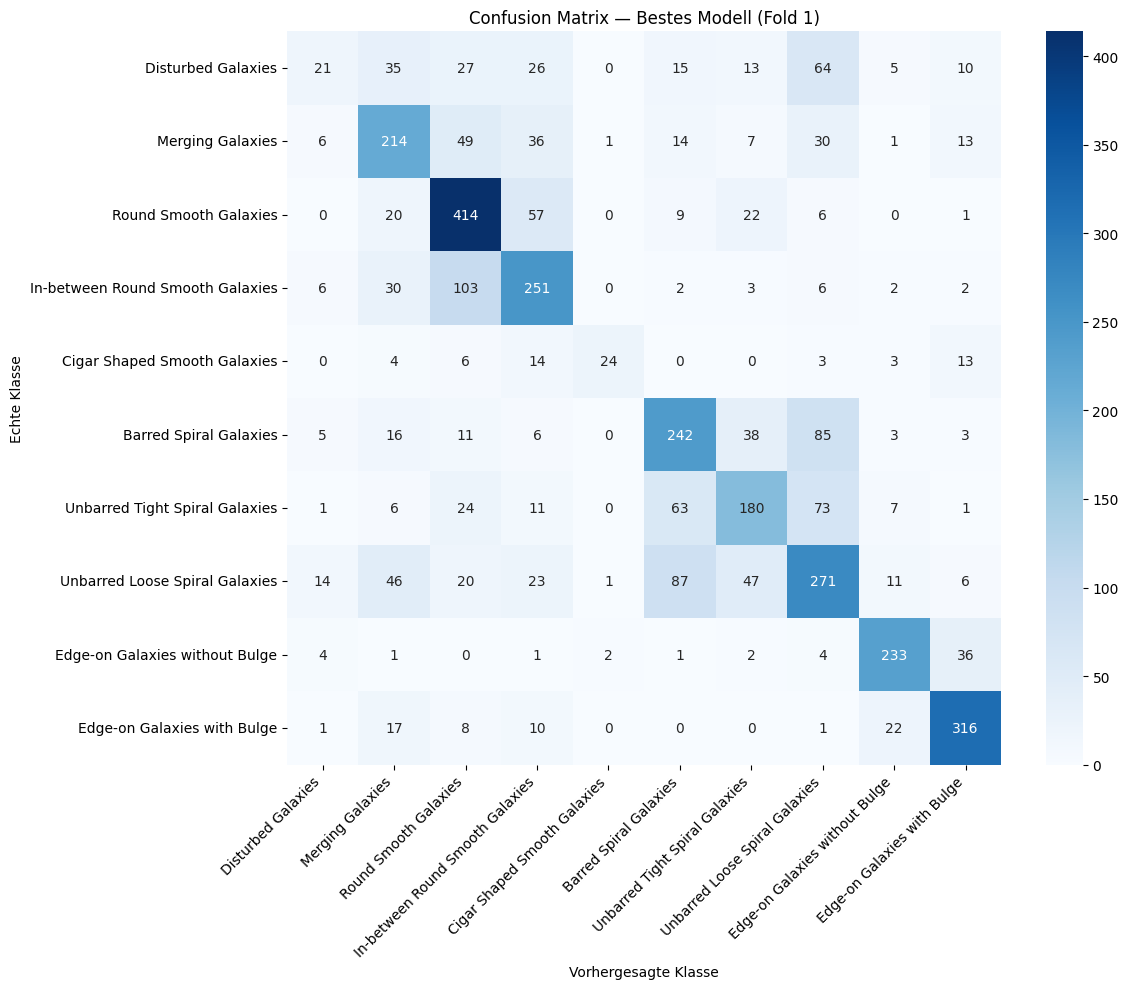



********************************************************************************
EVALUIERUNG FÜR: Zoobot_EfficientNetB0
********************************************************************************
Training History gespeichert: ./../logs//transfer_learning/zoobot_efficientnetb0/training_history.png


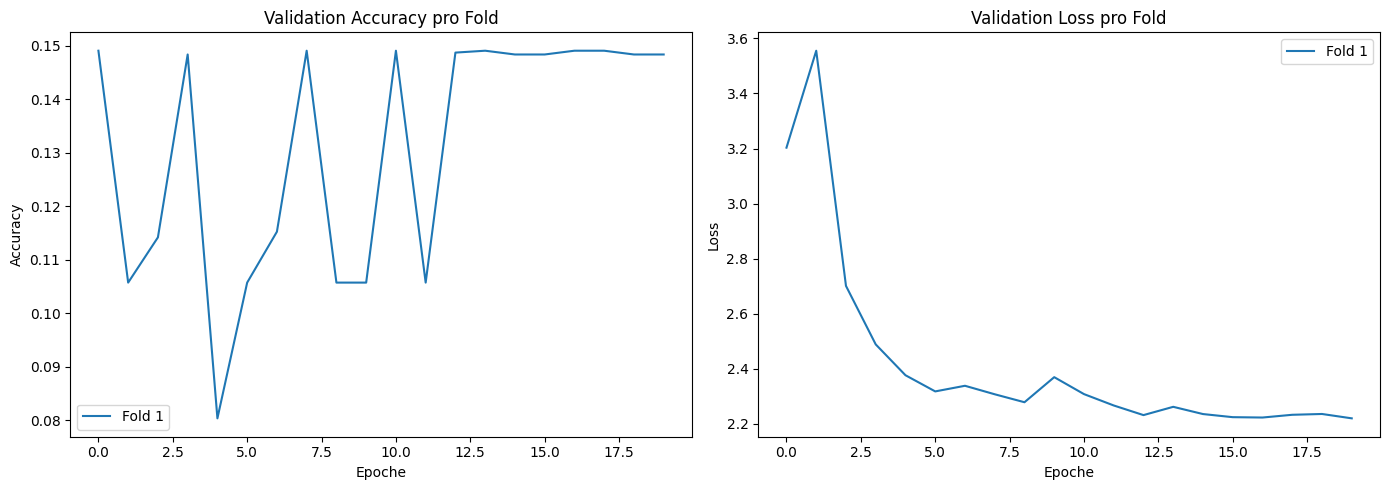

Starte Evaluierung auf dem Test-Set...

  Fold 1 / 1:
  1/222 ━━━━━━━━━━━━━━━━━━━━ 27s 124ms/step - accuracy: 0.0625 - loss: 2.2166

/home/alexa/Projects/deep-learning/tf-gpu-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


219/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1471 - loss: 2.2173

E0000 00:00:1779808202.859449    8834 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779808204.239841    8834 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


222/222 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.1483 - loss: 2.2199
  --> Test Accuracy: 0.1483 (14.83 %)

Durchschnittliche Test Accuracy : 0.1483
Standardabweichung              : 0.0000
Bestes Modell                   : Fold 1
  Test Accuracy                 : 0.1483 (14.83 %)
222/222 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step
Confusion Matrix gespeichert: ./../logs//transfer_learning/zoobot_efficientnetb0/confusion_matrix.png


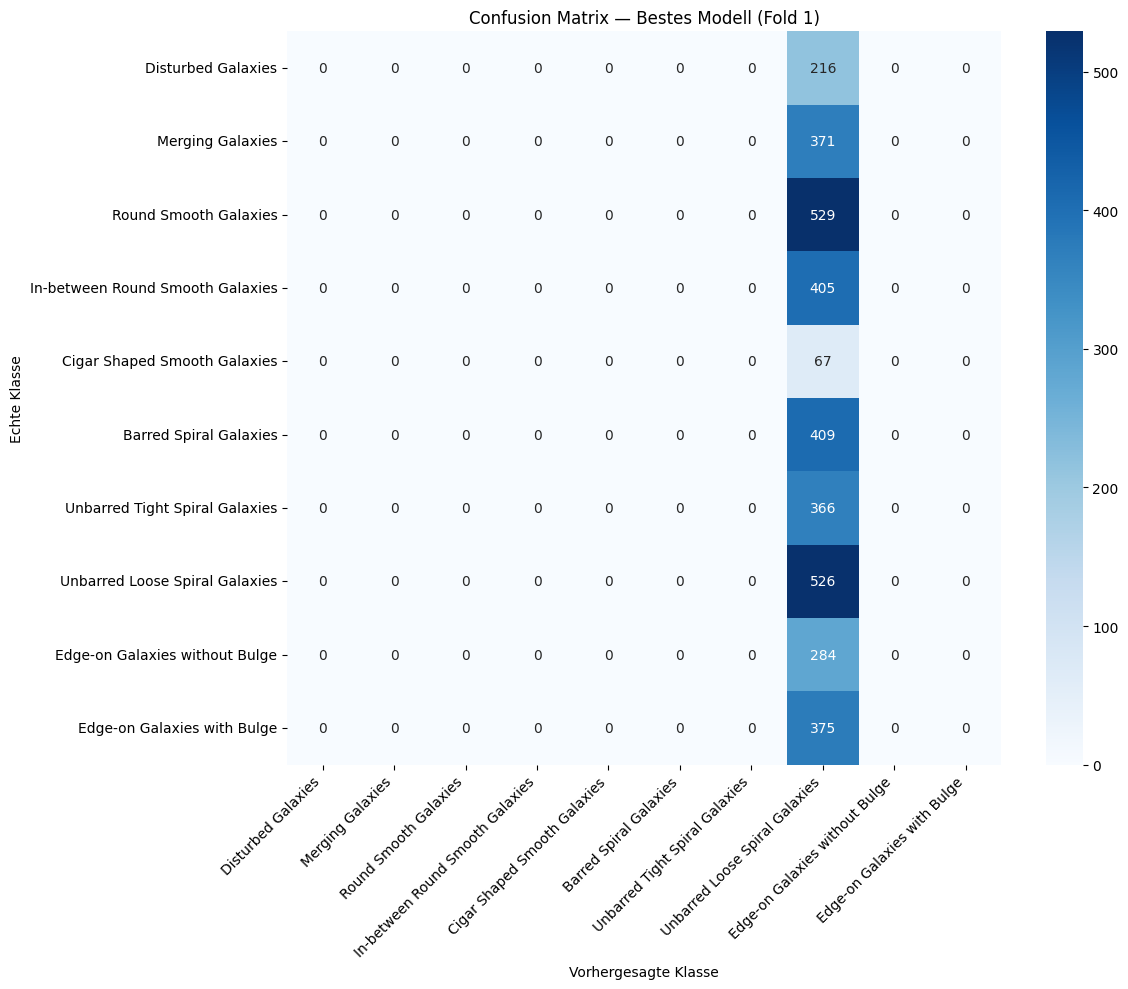

In [18]:
for model_name, results in training_results.items():
    print(f"\n\n{'*' * 80}")
    print(f"EVALUIERUNG FÜR: {model_name}")
    print(f"{'*' * 80}")
    
    log_dir = results["log_dir"]
    fold_models = results["models"]
    fold_histories = results["histories"]
    
    # 1. Plot der Trainings-Historie
    plot_training_history(fold_histories, save_dir=log_dir)
    
    # 2. Evaluation auf dem unseen Test-Set
    test_accuracies, best_model, best_fold_idx = evaluate_models(
        fold_models=fold_models,
        images_raw=images_raw,
        labels=labels,
        X_test=X_test,
        batch_size=BATCH_SIZE
    )
    
    # 3. Confusion Matrix des besten Folds
    cm_path = os.path.join(log_dir, "confusion_matrix.png")
    plot_confusion_matrix(
        best_model=best_model,
        images_raw=images_raw,
        labels=labels,
        X_test=X_test,
        best_fold_idx=best_fold_idx,
        batch_size=BATCH_SIZE,
        save_path=cm_path
    )

## 5. (Optional) Fine-Tuning des besten Modells

Wenn eines der Modelle besonders gut abgeschnitten hat, kannst du hier die Schichten des vortrainierten Backbones auftauen und mit einer sehr kleinen Lernrate (`1e-5`) für ein paar weitere Epochen trainieren (Fine-Tuning).

In [19]:
# Wenn du das Fine-Tuning ausführen möchtest, ändere False zu True
DO_FINETUNING = False

if DO_FINETUNING:
    print("Starte Fine-Tuning für das insgesamt beste Modell...")
    
    # Beispiel: Nimm das beste Modell aus der Inception-Familie
    best_overall_model = training_results["InceptionV3"]["models"][0] # Hier anpassen!
    
    # 1. Auftauen (Batch Normalization bleibt sicherheitshalber oft eingefroren)
    for layer in best_overall_model.layers:
        if not isinstance(layer, BatchNormalization):
            layer.trainable = True
            
    # 2. Neu kompilieren mit SEHR kleiner Lernrate
    best_overall_model.compile(
        optimizer=Adam(learning_rate=1e-5), 
        loss="categorical_crossentropy", 
        metrics=["accuracy"]
    )
    
    # Da run_training Factories erwartet, würden wir hier manuell .fit() aufrufen
    # oder eine dedizierte Fine-Tuning-Funktion schreiben.
    print("Modell aufgetaut und bereit für manuelles .fit()")